<a href="https://colab.research.google.com/github/lecacung-ai/TH_DeepLearning/blob/main/BUOI2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NẠP THƯ VIỆN

In [4]:
#install required libraries
import pandas as pd
import numpy as np
#data visualization packages
import matplotlib.pyplot as plt
#keras packages
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
#from keras.wrappers.scikit_learn import KerasClassifier  # Removed deprecated import
from keras.layers import Dropout
#model evaluation packages
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

ĐỌC TẬP DỮ LIỆU FASHION MNIST

In [5]:
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


XỬ LÝ DỮ LIỆU

In [6]:
#reshape data from 3-D to 2-D array
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

#feature scaling
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


TRỰC QUAN DỮ LIỆU

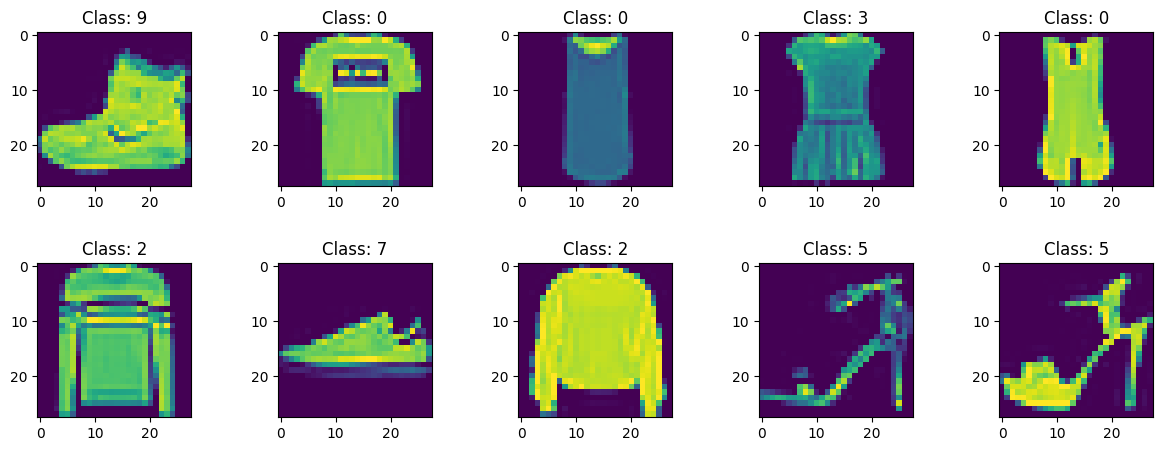

In [7]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text("Class: " + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

XÂY DỰNG MÔ HÌNH HỌC ANN

In [8]:
#initial ANN model
fashion_model = Sequential()

#add first hidden layer
fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

#add output layer
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

#compile neural network
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#model summary
fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

HUẤN LUYỆN ANN

In [9]:
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8210 - loss: 0.5074 - val_accuracy: 0.8478 - val_loss: 0.4138
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8646 - loss: 0.3733 - val_accuracy: 0.8648 - val_loss: 0.3704
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8789 - loss: 0.3321 - val_accuracy: 0.8758 - val_loss: 0.3355
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8862 - loss: 0.3060 - val_accuracy: 0.8773 - val_loss: 0.3487
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8945 - loss: 0.2863 - val_accuracy: 0.8843 - val_loss: 0.3235
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8987 - loss: 0.2732 - val_accuracy: 0.8853 - val_loss: 0.3384
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9040 - loss: 0.2567 - val_accuracy: 0.8857 - val_loss: 0.3252
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9076 - loss: 0.24

ĐÁNH GIÁ ANN

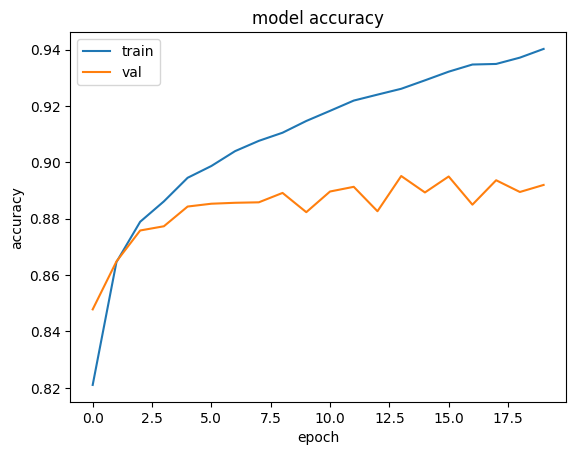

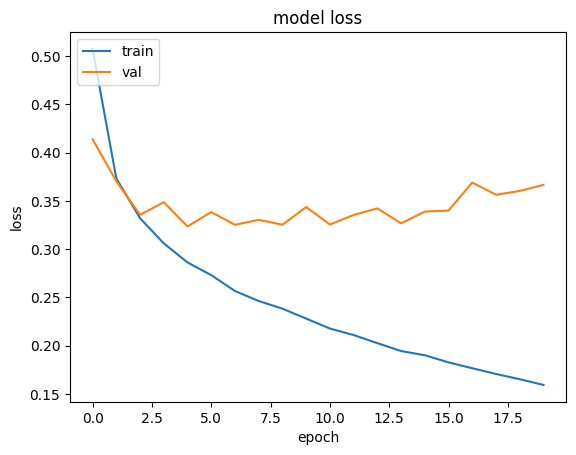

In [10]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

DỰ BÁO ẢNH MỚI

In [11]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
4 4


ĐỌC DỮ LIỆU TỪ FILE

In [13]:
mnist_train_path = '/content/sample_data/mnist_train_small.csv'
mnist_test_path = '/content/sample_data/mnist_test.csv'

mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)

print(mnist_train.head())
print(mnist_train.shape)

X_train = mnist_train.iloc[:, 1:]
X_test = mnist_test.iloc[:, 1:]
print(X_train.shape)

y_train = mnist_train.iloc[:, 0]
y_test = mnist_test.iloc[:, 0]

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

model_fit = model.fit(X_train, y_train, epochs=30, verbose=1)
print(np.argmax(model.predict(X_test)[0]), y_test[0])

   6  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.581  0.582  0.583  \
0  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  7  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.584  0.585  0.586  0.587  0.588  0.589  0.590  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]
(19999, 785)
(19999, 784)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8750 - loss: 1.1336
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9356 - loss: 0.2372
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9484 - loss: 0.1900
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9452 - loss: 0.2117
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9442 - loss: 0.2362
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9492 - loss: 0.2182
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9544 - loss: 0.1998
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9601 - loss: 0.1815
Epoch 9/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9644 - loss: 0.1643
Epoch 10/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9632 - loss: 0.1856
Epoch 11/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9668 - loss: 0.1577
Epoch 12/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step

DỰA VÀO LEAK DATA TRAIN, REGRESSION VỚI ANN

NẠP THƯ VIỆN

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

GIẢ LẬP DỮ LIỆU

In [15]:
np.random.seed(42)
X = np.random.rand(1000, 5) * 100
y = 2.5 * X[:, 0] - 1.5 * X[:, 1] + 0.8 * X[:, 2] + np.random.randn(1000) * 5

CHIA DỮ LIỆU

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Kích thước tập dữ liệu huấn luyện (Train):", X_train.shape)
print("Kích thước tập dữ liệu kiểm tra (Test):", X_test.shape)

Kích thước tập dữ liệu huấn luyện (Train): (800, 5)
Kích thước tập dữ liệu kiểm tra (Test): (200, 5)


CHUẨN HOÁ DỮ LIỆU

In [17]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

XÂY DỰNG KIẾN TRÚC MẠNG

In [18]:
regression_model = Sequential()
regression_model.add(Dense(input_dim=X_train_scaled.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
regression_model.add(Dropout(0.2))
regression_model.add(Dense(units=128, kernel_initializer='uniform', activation='relu'))
regression_model.add(Dropout(0.2))
regression_model.add(Dense(units=1, kernel_initializer='uniform', activation='linear'))
regression_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
regression_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,561 (135.00 KB)

 Trainable params: 34,561 (135.00 KB)

 Non-trainable params: 0 (0.00 B)

HUẤN LUYỆN

In [19]:
model_fit = regression_model.fit(X_train_scaled, y_train, validation_split=0.1, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 15983.7432 - mae: 104.1984 - val_loss: 16381.2715 - val_mae: 104.0664
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15270.1318 - mae: 101.6273 - val_loss: 14709.8613 - val_mae: 98.0631
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12517.3379 - mae: 91.4856 - val_loss: 10260.7598 - val_mae: 81.7678
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8576.1406 - mae: 75.8862 - val_loss: 6953.1279 - val_mae: 69.1131
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7165.7026 - mae: 69.0329 - val_loss: 6180.9868 - val_mae: 65.7945
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6331.0620 - mae: 64.7974 - val_loss: 5487.1689 - val_mae: 61.5336
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5458.7788 - mae: 59.8494 - val_loss: 4569.4209 - val_mae: 56.6388
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4455.9609 - mae: 54.3651 - val_loss: 3606.0500 - val_mae: 50.064

ĐÁNH GIÁ VẼ ĐỒ THỊ


[KẾT QUẢ TẬP TEST] Mean Squared Error (MSE): 74.8623


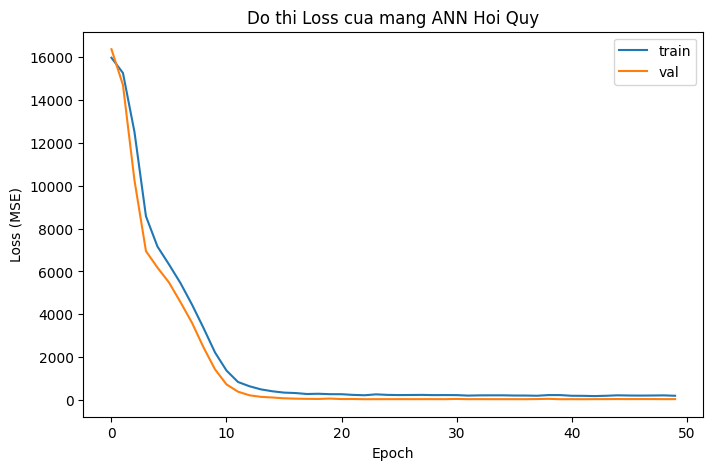

In [20]:
test_loss = regression_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n[KẾT QUẢ TẬP TEST] Mean Squared Error (MSE): {test_loss[0]:.4f}")
plt.figure(figsize=(8, 5))
plt.plot(model_fit.history['loss'], label='Train Loss (MSE)')
plt.plot(model_fit.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Do thi Loss cua mang ANN Hoi Quy')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

DỰ BÁO KẾT QUẢ THỰC TẾ

In [22]:
predictions = regression_model.predict(X_test_scaled)
print("\n--- SO SÁNH GIÁ TRỊ DỰ ĐOÁN VÀ THỰC TẾ ---")
for i in range(5):
    print(f"Mẫu ảnh/dữ liệu số {i+1} -> Hệ thống dự đoán: {predictions[i][0]:.2f} | Đáp án thực tế: {y_test[i]:.2f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

--- SO SÁNH GIÁ TRỊ DỰ ĐOÁN VÀ THỰC TẾ ---
Mẫu ảnh/dữ liệu số 1 -> Hệ thống dự đoán: 146.05 | Đáp án thực tế: 148.66
Mẫu ảnh/dữ liệu số 2 -> Hệ thống dự đoán: 34.66 | Đáp án thực tế: 34.32
Mẫu ảnh/dữ liệu số 3 -> Hệ thống dự đoán: 78.01 | Đáp án thực tế: 83.85
Mẫu ảnh/dữ liệu số 4 -> Hệ thống dự đoán: 4.47 | Đáp án thực tế: 11.69
Mẫu ảnh/dữ liệu số 5 -> Hệ thống dự đoán: 133.79 | Đáp án thực tế: 122.49
